# Gradient Descent

Gradient Descent is an optimization algorithm used to minimize a function by iteratively moving in the direction of the negative gradient.

$$
x_{k+1} = x_k - \eta_k \nabla f(x_k)
$$

where:

- $x_k$ - current point;
- $\eta_k$ - learning rate;
- $\nabla f(x_k)$ - gradient of the function

The goal of gradient descent is to minimize a function f(x).
In this project, we focus on comparing different learning rate schedules and their effect on convergence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Algorithm

At each iteration $k$:
1. Compute the gradient $∇f(x_k)$
2. Select learning rate $η_k$
3. Update parameters

In [2]:
def gradient_descent(grad_function, x0, lr_schedule, iterations=200):

  x = x0.copy()
  history = []

  for k in range(iterations):
    lr = lr_schedule(k)
    grad = grad_function(x)
    x = x - lr * grad
    history.append(x.copy())
  return x, history


## Constant Learning Rate

$$
\eta_k = \eta
$$

The learning rate is fixed during all iterations.

Key characteristics:

- simple;
- fast convergence (if chosen correctly);
- may diverge if too large.



In [3]:
def constant_lr(lr):
  return lambda k: lr

## Step Decay

$$
\eta_k = \frac{\eta_0}{2^{\left[ \frac{k}{k_1} \right]}}
$$

where $[k / k_1]$ denotes the integer part.

The learning rate decreases stepwise every $k_1$ iterations.

Key characteristics:
- large steps at the beginning;
- smaller steps later;
- may become too small too quickly.

In [4]:
def step_decay(lr, k1):

  def schedule(k):
    return lr / (2 ** (k // k1))

  return schedule

## Inverse Decay

$$
\eta_k = \frac{\eta_0}{1 + \alpha k}
$$

The learning rate decreases smoothly over time.

Key characteristics:
- stable convergence;
- typically slower than the constant learning rate schedule.

In [5]:
def inverse_decay(lr, alpha):

  def schedule(k):
    return lr /(1 + alpha * k)

  return schedule

## Optimization Problem

We considera quadratic function:

$$
f(x) = x^T A x
$$

where
$$
A = \operatorname{diag}(a_1, \dots, a_n), \quad a_i > 0
$$

Thus, $A$ is a diagonal positive definite matrix.

Gradient:

$$
\nabla f(x) = 2Ax
$$

This is a convex function with a global minimum at:

$$
x = 0
$$

This quadratic objective is commonly used as a benchmark for testing optimization algorithms.

In [6]:
def quadratic(x, A):
  return x.T @ A @ x

def quadratic_grad(x, A):
  return 2 * A @ x

## Experiments

We compare different learning rate schedules:

- constant learning rate;
- step decay;
- inverse decay.

We evalute:

- convergence speed;
- stability;
- final objective value.

In [7]:
def run_experiment(n, A, x0, iterations=200, lr0=0.1, k1=10, alpha=0.05):
  lr_const = constant_lr(lr0)
  lr_step = step_decay(lr0, k1=k1)
  lr_inv = inverse_decay(lr0, alpha=alpha)

  _, hist_const = gradient_descent(
      lambda x: quadratic_grad(x, A), x0, lr_const, iterations=iterations
  )
  _, hist_step = gradient_descent(
      lambda x: quadratic_grad(x, A), x0, lr_step, iterations=iterations
  )
  _, hist_inv = gradient_descent(
      lambda x: quadratic_grad(x, A), x0, lr_inv, iterations=iterations
  )

  values_const = [quadratic(x, A) for x in hist_const]
  values_step = [quadratic(x, A) for x in hist_step]
  values_inv = [quadratic(x, A) for x in hist_inv]

  return values_const, values_step, values_inv

## Convergence Plots

The following plots show how the function value decreases during optimization.

A steeper decrease indicates faster convergence.

In [8]:
def plot_experiment(values_const, values_step, values_inv, title, log_scale=False):
  plt.figure(figsize=(8, 5))

  plt.plot(values_const, label="Constant LR")
  plt.plot(values_step, label="Step Decay")
  plt.plot(values_inv, label="Inverse Decay")

  plt.xlabel("Iteration")
  plt.ylabel("Function value")
  plt.title(title)
  plt.legend()
  plt.grid(True, alpha=0.3)

  if log_scale:
    plt.yscale("log")

  plt.show()

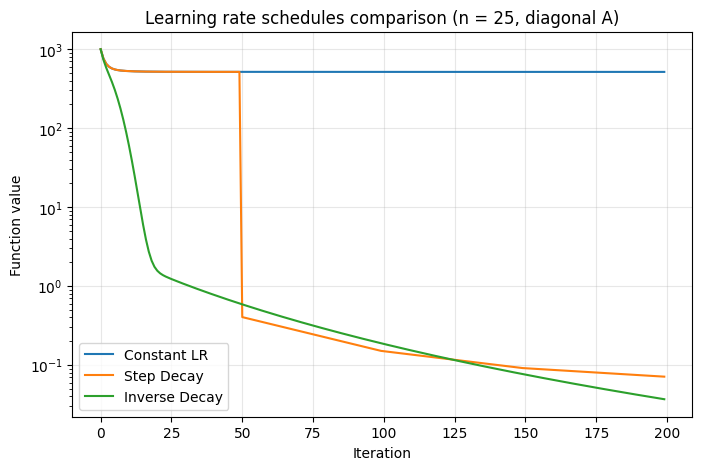

In [9]:
np.random.seed(0)

n = 25
A = np.diag(np.linspace(1, 100, n))
x0 = np.random.randn(n)

values_const, values_step, values_inv = run_experiment(
    n=n,
    A=A,
    x0=x0,
    iterations=200,
    lr0=0.01,
    k1=50,
    alpha=0.01
)

plot_experiment(
    values_const,
    values_step,
    values_inv,
    title="Learning rate schedules comparison (n = 25, diagonal A)",
    log_scale=True
)

## Numerical Comparison

In [10]:
summary = pd.DataFrame({
    "Method": ["Constant LR", "Step Decay", "Inverse Decay"],
    "Final objective value": [values_const[-1], values_step[-1], values_inv[-1]]
})

summary

,Method,Final objective value
0,Constant LR,515.179568
1,Step Decay,0.071244
2,Inverse Decay,0.036895


## Conclusion

The constant learning rate shows poor performance with a high final objective value, indicating unstable or inefficient convergence.

In contrast, both step decay and inverse decay significantly improve convergence. Inverse decay achieves the lowest final objective value, demonstrating more stable and adaptive behavior.

This suggests that adaptive learning rate schedules are more robust than a fixed learning rate.

To better understand the behavior of the constant learning rate, we analyze its sensitivity to the choice of the learning rate parameter.

## Sensitivity to Learning Rate (Constant Schedule)

In [11]:
learning_rates = [0.01, 0.005, 0.001, 0.0005]

results = []

for lr in learning_rates:
    values_const, _, _ = run_experiment(
        n=n,
        A=A,
        x0=x0,
        iterations=200,
        lr0=lr,
        k1=50,
        alpha=0.01
    )

    results.append({
        "Learning rate": lr,
        "Final objective value": values_const[-1]
    })

pd.DataFrame(results)

,Learning rate,Final objective value
0,0.0100,515.179568
1,0.0050,0.055860
2,0.0010,1.416856
3,0.0005,2.769849


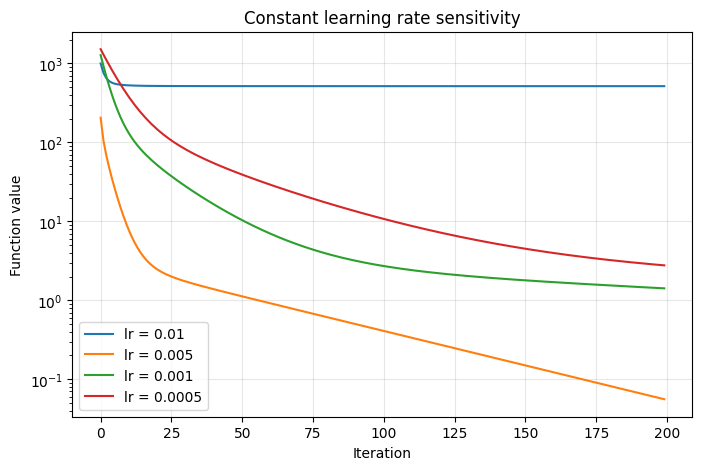

In [12]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    values_const, _, _ = run_experiment(
        n=n,
        A=A,
        x0=x0,
        iterations=200,
        lr0=lr,
        k1=50,
        alpha=0.01
    )
    plt.plot(values_const, label=f"lr = {lr}")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Function value")
plt.title("Constant learning rate sensitivity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The results show that constant learning rate performance strongly depends on the selected step size. A large learning rate may lead to poor convergence, while a smaller one can improve stability but may slow down optimization.

This confirms that the main limitation of a constant learning rate is not that it is fixed by itself, but that it requires careful tuning and cannot adapt during optimization.

## Final Conclusion

In this project, we compared different learning rate schedules for gradient descent on a quadratic optimization problem.

The results show that a constant learning rate is highly sensitive to the choice of the step size and may lead to poor convergence if not properly tuned.

In contrast, step decay and inverse decay provide more robust behavior by adapting the learning rate during optimization. Among them, inverse decay achieved the best performance, demonstrating stable and efficient convergence.

Overall, adaptive learning rate schedules provide more reliable and stable convergence in practice.